1. Importando Bibliotecas

In [6]:
# O "%" significa que o comando será executado a nível de sistema operacional
%pip install -q -U watermark 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install pandas numpy matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Pandas serve para manipulação de dados em tabelas
import pandas as pd

# NumPy serve para operações matemáticas e arrays
import numpy as np

# Matplotlib serve para geração de gráficos
import matplotlib.pyplot as plt

# Seaborn serve para visualização de estatísticas sobre os dados
import seaborn as sns

# Random serve para geração de números aleatórios
import random 

# Datetime e Timedelta servem para trabalhar com intervalos de tempo 
from datetime import datetime, timedelta

# Comando para exibir gráficos no notebook
%matplotlib inline

In [7]:
%reload_ext watermark 
%watermark -a "Gabriel Alves"

Author: Gabriel Alves



In [8]:
%watermark --iversions

matplotlib: 3.10.9
numpy     : 2.4.6
pandas    : 3.0.3
seaborn   : 0.13.2



# 3. Função para geração de dados fictícios

In [ ]:
def gerar_dados_ficticios(num_registros=600):
    """
    Gera um DataFrame do Pandas com dados de vendas fictícios
    """

    print(f"Iniciando a geração de {num_registros} de vendas...")

    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco' : 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco' : 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco' : 600.00}
    }

    lista_produtos = list(produtos.keys())

    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre' : 'RS', 'Salvador' : 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }

    lista_cidades = list(cidades_estados.keys())

    dados_vendas = []

    data_inicial = datetime(2026, 1, 1)

    for i in range(num_registros):
        produto_nome = random.choice(lista_produtos)
        cidade = random.choice(lista_cidades)
        quantidade = np.random.randint(1,8)
        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)
        else: 
            preco_unitario = produtos[produto_nome]['preco']

        dados_vendas.append({
            "ID_Pedido": 1000 + i,
            "Data_Pedido": data_pedido,
            "Nome_Produto": produto_nome,
            "Categoria": produtos[produto_nome]["categoria"],
            "Preco_Unitario": round(preco_unitario, 2),
            "Quantidade": quantidade,
            "ID_Cliente": np. random. randint(100, 150),
            "Cidade": cidade,
            "Estado": cidades_estados [cidade]
        })

    print("Geração concluída")
    return pd.DataFrame(dados_vendas)

4. Gerar, carregar e explorar os dados

In [10]:
df_vendas = gerar_dados_ficticios(1000)

Iniciando a geração de {num_registros} de vendas...
Geração concluída


In [ ]:
df_vendas.shape

# saída = (linha, coluna)

(1000, 9)

In [13]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 09:00:00,Placa de Vídeo,Hardware,4500.00,6,121,Salvador,BA
1,1001,2026-01-01 08:00:00,Placa de Vídeo,Hardware,4500.00,7,116,Rio de Janeiro,RJ
2,1002,2026-01-01 12:00:00,Teclado Mecânico,Acessórios,519.33,7,109,Porto Alegre,RS
3,1003,2026-01-01 04:00:00,SSD 1TB,Hardware,600.00,7,120,Rio de Janeiro,RJ
4,1004,2026-01-01 05:00:00,Monitor Ultrawide,Eletrônicos,2800.00,3,132,Belo Horizonte,MG


In [14]:
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
995,1995,2026-07-19 07:00:00,Mouse Vertical,Acessórios,235.78,4,141,Rio de Janeiro,RJ
996,1996,2026-07-19 02:00:00,Headset 7.1,Acessórios,800.00,4,125,Curitiba,PR
997,1997,2026-07-19 09:00:00,Placa de Vídeo,Hardware,4500.00,4,134,Rio de Janeiro,RJ
998,1998,2026-07-19 01:00:00,SSD 1TB,Hardware,600.00,4,137,Belo Horizonte,MG
999,1999,2026-07-19 09:00:00,Monitor Ultrawide,Eletrônicos,2800.00,2,119,São Paulo,SP


In [15]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       1000 non-null   int64         
 1   Data_Pedido     1000 non-null   datetime64[us]
 2   Nome_Produto    1000 non-null   str           
 3   Categoria       1000 non-null   str           
 4   Preco_Unitario  1000 non-null   float64       
 5   Quantidade      1000 non-null   int64         
 6   ID_Cliente      1000 non-null   int64         
 7   Cidade          1000 non-null   str           
 8   Estado          1000 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 70.4 KB


In [ ]:
df_vendas.describe() # gera um resumo estatístico

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,1000.000000,1000,1000.000000,1000.000000,1000.000000
mean,1499.500000,2026-04-10 23:10:08.400000,2310.087060,4.109000,124.431000
min,1000.000000,2026-01-01 04:00:00,225.010000,1.000000,100.000000
25%,1249.750000,2026-02-19 23:15:00,600.000000,2.000000,112.000000
50%,1499.500000,2026-04-10 20:30:00,1200.000000,4.000000,124.000000
75%,1749.250000,2026-05-31 00:15:00,4500.000000,6.000000,136.250000
max,1999.000000,2026-07-19 09:00:00,7500.000000,7.000000,149.000000
std,288.819436,NaN,2386.019246,1.984202,14.352046


In [ ]:
df_vendas.dtypes # retorna os tipos de dados

ID_Pedido                  int64
Data_Pedido       datetime64[us]
Nome_Produto                 str
Categoria                    str
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                       str
Estado                       str
dtype: object

4. Limpeza, pré processamento e engenharia de atributos

In [19]:
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido']) # converte a coluna para datetime

In [20]:
# Engenharia de atributos (complementando os registros)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade'] # a informação já existia mas estava ímplicita

In [21]:
# Usando uma função lambda para determinar o tipo de entrega (engenharia de atributos)
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápida' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [22]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 09:00:00,Placa de Vídeo,Hardware,4500.00,6,121,Salvador,BA,27000.00,Normal
1,1001,2026-01-01 08:00:00,Placa de Vídeo,Hardware,4500.00,7,116,Rio de Janeiro,RJ,31500.00,Rápida
2,1002,2026-01-01 12:00:00,Teclado Mecânico,Acessórios,519.33,7,109,Porto Alegre,RS,3635.31,Normal
3,1003,2026-01-01 04:00:00,SSD 1TB,Hardware,600.00,7,120,Rio de Janeiro,RJ,4200.00,Rápida
4,1004,2026-01-01 05:00:00,Monitor Ultrawide,Eletrônicos,2800.00,3,132,Belo Horizonte,MG,8400.00,Rápida


6. Extraindo os 10 produtos mais vendidos

In [ ]:
# Nesse contexto o critério é quantidade, mas poderia ser vendas ou outros (validar com a área de negócios)
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending=False).head(10)

In [24]:
top_10_produtos

Nome_Produto
Placa de Vídeo       572
Cadeira Gamer        564
Mouse Vertical       526
Laptop Gamer         511
Headset 7.1          499
Monitor Ultrawide    497
SSD 1TB              476
Teclado Mecânico     464
Name: Quantidade, dtype: int64

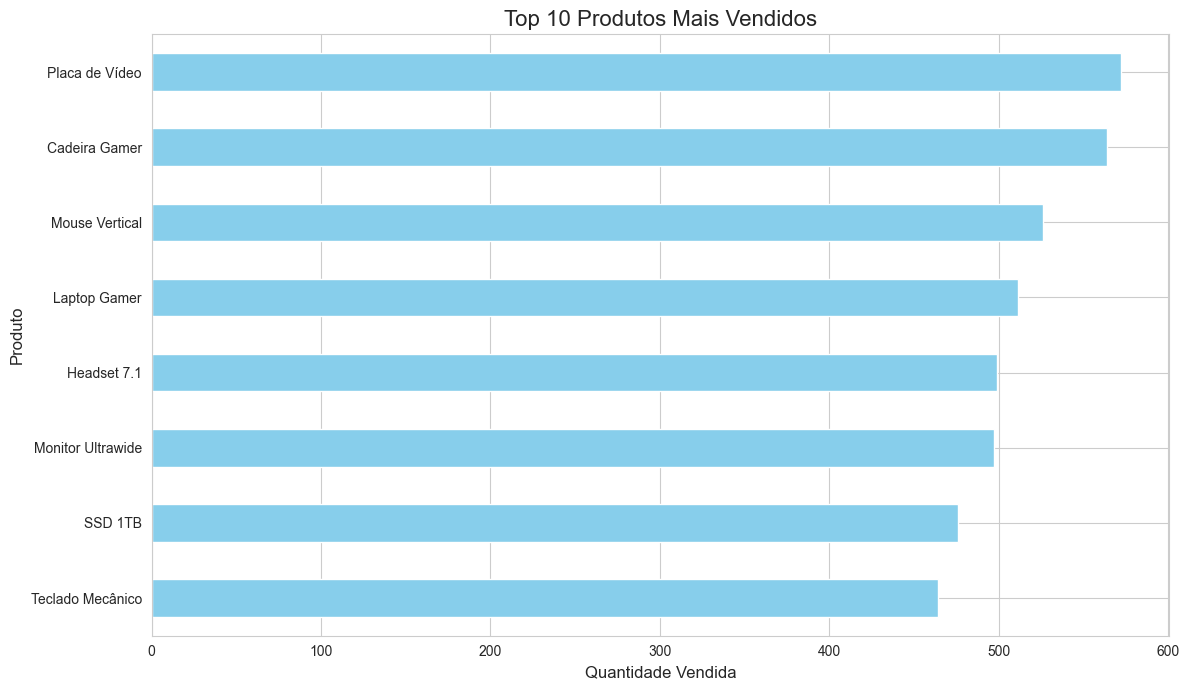

In [26]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 7))

top_10_produtos.sort_values(ascending=True).plot(kind='barh', color='skyblue')

plt.title('Top 10 Produtos Mais Vendidos', fontsize=16)
plt.xlabel('Quantidade Vendida', fontsize=12)
plt.ylabel('Produto', fontsize=12)

plt.tight_layout()
plt.show()
